# 05. 모델 비교 (LSTM vs DistilBERT)

두 모델의 test 지표(Accuracy/F1)를 비교표로 만들고 `models/comparison.md`에 저장한다.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
from src.config import MODEL_DIR, OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load(name):
    return json.loads((MODEL_DIR / name / "metrics.json").read_text())

rows = {"LSTM": load("lstm"), "DistilBERT": load("distilbert")}
lines = ["| 모델 | Accuracy | F1 |", "|---|---|---|"]
for name, m in rows.items():
    lines.append(f"| {name} | {m['accuracy']:.4f} | {m['f1']:.4f} |")
table = "\n".join(lines)
print(table)
(MODEL_DIR / "comparison.md").write_text(table + "\n")

| 모델 | Accuracy | F1 |
|---|---|---|
| LSTM | 0.8190 | 0.9004 |
| DistilBERT | 0.9034 | 0.9415 |


97

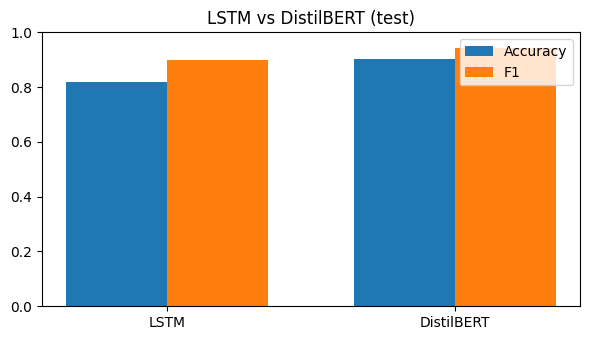

In [2]:
import matplotlib.pyplot as plt

names = list(rows)
fig, ax = plt.subplots(figsize=(6, 3.5))
x = range(len(names))
w = 0.35
ax.bar([i - w / 2 for i in x], [rows[n]["accuracy"] for n in names], w, label="Accuracy")
ax.bar([i + w / 2 for i in x], [rows[n]["f1"] for n in names], w, label="F1")
ax.set_xticks(list(x), names)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("LSTM vs DistilBERT (test)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()